# Лабораторная работа 6. Генерация текста по символам

Подключите к среде видеокарту, обучение нейронных сетей выполняйте на GPU. \
**Ориентируйтесь** на максимальное время обучения в рамках одного эксперимента - шесть минут.

Импортируем необходимые библиотеки для работы.

In [1]:
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import random
import matplotlib.pyplot as plt
import numpy as np
import torch
from tqdm import tqdm

In [2]:
def seed_everything(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed) # для multi-GPU
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

Создадим класс датасета, который позволит, используя DataLoader, удобно формировать батчи для обучения.

In [3]:
class TextDataset(Dataset):
    def __init__(self, tokenized_texts):
        self.data = tokenized_texts

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        text = self.data[idx]
        x = text[:-1]
        y = text[1:]
        return x, y

Также добавим важные функции для работы с тестовыми данными.

In [4]:
def char_to_tensor(string, vocabulary):
    tensor = torch.zeros(len(string)).long()
    for c in range(len(string)):
        tensor[c] = vocabulary.index(string[c])
    return tensor

def tensor_to_char(tensor, vocabulary):
    s = ''
    for t in tensor:
        s += vocabulary[int(t)]
    return s

def random_sequence(data, seq_len):
    start_index = random.randint(0, len(data) - seq_len - 1)
    end_index = start_index + seq_len + 1
    return data[start_index:end_index]

Создадим датасет и загрузчик данных для обучения, которые случайно "нарежем" отрывками длины `seq_len` из текста файла `Метафизика. Аристотель.txt` (текст взят с ресурса - https://lib.ru/POEEAST/ARISTOTEL/metaphiz.txt_with-big-pictures.html).

In [22]:
seq_len = 200
batch_size = 512

seed_everything()

filename = 'Метафизика. Аристотель.txt'
with open(filename, encoding='utf-8') as f:
    data = f.read()
print(f'Длина текста: {len(data)} символов')
print(f'\nПервые {seq_len} строк:\n\n{data[:seq_len]}')

data = data.lower()

vocabulary = set(data)
vocabulary = sorted(vocabulary)
print(f'Размер словаря: {len(vocabulary)}')
print(vocabulary)

train_sequences = [char_to_tensor(random_sequence(data, seq_len), vocabulary) for _ in range(3000)]
train_dataset = TextDataset(train_sequences)

train_loader = DataLoader(
    dataset=train_dataset,
    batch_size=batch_size,
    shuffle=True,
    drop_last=False,
    num_workers=0
)

Длина текста: 611964 символов

Первые 200 строк:

Аристотель. Метафизика

ГЛАВА ПЕРВАЯ


      Все люди от природы стремятся к знанию. Доказательство тому - влечение к чувственным восприятиям: ведь независимо от того, есть от них польза или нет, их ц
Размер словаря: 81
['\n', ' ', '"', "'", '(', ')', '*', '+', ',', '-', '.', '0', '1', '2', '3', '4', '5', '6', '7', '8', '9', ':', ';', '<', '>', '?', '[', ']', 'a', 'b', 'c', 'd', 'e', 'g', 'h', 'i', 'k', 'l', 'm', 'n', 'o', 'p', 'r', 's', 't', 'u', 'x', 'y', 'z', 'а', 'б', 'в', 'г', 'д', 'е', 'ж', 'з', 'и', 'й', 'к', 'л', 'м', 'н', 'о', 'п', 'р', 'с', 'т', 'у', 'ф', 'х', 'ц', 'ч', 'ш', 'щ', 'ъ', 'ы', 'ь', 'э', 'ю', 'я']


Определим класс нейронной сети на основе Simple RNN.

In [23]:
class RNN(nn.Module):
    def __init__(self, embedding_size, hidden_size, num_layers=1):

        super(RNN, self).__init__()

        self.hidden_size = hidden_size
        self.num_layers = num_layers

        self.embedding = nn.Embedding(num_embeddings=len(vocabulary), embedding_dim=embedding_size)
        self.rnn = nn.RNN(input_size=embedding_size, hidden_size=hidden_size, num_layers=num_layers, batch_first=True)
        self.decoder = nn.Linear(in_features=hidden_size, out_features=len(vocabulary))

    def forward(self, input, hidden):
        embeddings = self.embedding(input)
        output, hidden = self.rnn(embeddings, hidden)
        output = self.decoder(output) #[:,-1,:])
        return output, hidden

    def init_hidden(self, batch_size):
        return torch.zeros(self.num_layers, batch_size, self.hidden_size)

Функцию генерации по текстовому префиксу организуем следуюшим образом:

In [10]:
def generate_text(model, input_seq, generated_length, vocabulary, temperature=1.0, device='cpu'):
    model.eval()
    model.to(device)
    hidden = model.init_hidden(1).to(device)
    generated_text = tensor_to_char(input_seq, vocabulary)
    inputs = input_seq.reshape(1,-1).to(device)

    with torch.no_grad():
      outputs, hidden = model(inputs, hidden)
      next_token_logits = outputs[:, -1, :] / temperature
      probabilities = F.softmax(next_token_logits, dim=-1).squeeze(0)
      predicted_idx = torch.multinomial(probabilities, num_samples=1).item()

      generated_text += tensor_to_char([predicted_idx], vocabulary)

      for _ in range(generated_length - 1):
        inputs = torch.tensor([[predicted_idx]], dtype=torch.long).to(device)
        outputs, hidden = model(inputs, hidden)

        next_token_logits = outputs[:, -1, :] / temperature
        probabilities = F.softmax(next_token_logits, dim=-1).squeeze(0)

        predicted_idx = torch.multinomial(probabilities, num_samples=1).item()
        generated_text += tensor_to_char([predicted_idx], vocabulary)

    return generated_text

Также добавим функцию обучения на одной эпохе:

In [11]:
def train_epoch(model, dataloader, optimizer, criterion, device):
    model.train()
    epoch_loss = 0.0

    for inputs, targets in dataloader:
        inputs = inputs.to(device)    # Размерность: [batch_size, sequence_length]
        targets = targets.to(device)  # Размерность: [batch_size] (индекс следующего токена)

        batch_size = inputs.size(0)

        optimizer.zero_grad()

        hidden = model.init_hidden(batch_size).to(device)

        outputs, hidden = model(inputs, hidden) #Размерность: [batch_size, len(vocabulary)]

        loss = criterion(outputs.view(-1, len(vocabulary)), targets.view(-1))

        loss.backward()
        optimizer.step()

        epoch_loss += loss.item()

    return epoch_loss / len(dataloader)

Создадим нейронную сеть и посмотрим, что она генерирует по текстовому префиксу: \
`Все люди от природы стремятся к знанию`.

In [24]:
embedding_size = 16
num_layers = 1
hidden_size = 32
seed_everything()

rnn = RNN(embedding_size=embedding_size,
          hidden_size=hidden_size,
          num_layers=num_layers
)
generate_text(rnn, char_to_tensor("Все люди от природы стремятся к знанию".lower(), vocabulary), 20, vocabulary)

'все люди от природы стремятся к знанию"бдr .k,a-oе(эg+4umз'

Обучим сеть на данных.

In [25]:
embedding_size = 16
num_layers = 1
hidden_size = 32
n_epochs = 1000
device = "cuda"
seed_everything()

rnn = RNN(embedding_size=embedding_size,
          hidden_size=hidden_size,
          num_layers=num_layers
).to(device)

trainable_params = sum(p.numel() for p in rnn.parameters() if p.requires_grad)
print(f"Количество обучаемых параметров: {trainable_params}")

rnn_optimizer = torch.optim.AdamW(rnn.parameters(), lr=0.001)
criterion = nn.CrossEntropyLoss()

all_losses = []
loss_avg = 0

for epoch in tqdm(range(1, n_epochs + 1)):
  loss = train_epoch(rnn, train_loader, rnn_optimizer, criterion, device)
  all_losses.append(loss)

Количество обучаемых параметров: 5569


100%|██████████| 1000/1000 [01:05<00:00, 15.19it/s]


Посмотрим график потерь на обучающей выборке

Text(0.5, 0, 'epochs')

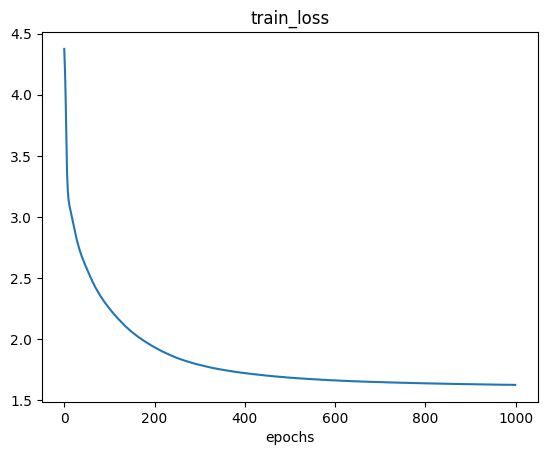

In [26]:
plt.figure()
plt.plot(all_losses)
plt.title("train_loss")
plt.xlabel('epochs')

Повторим генерацию по прежнему текстовому префиксу.

In [27]:
generate_text(rnn, char_to_tensor("Все люди от природы стремятся к знанию".lower(), vocabulary), 20, vocabulary)

'все люди от природы стремятся к знанию; очто вселенном сос'

##Задание 1.
Нарисуйте блок-схему с пояснениями процесса генерации текста заданной длины (уточните нюансы относительно размерностей, переменной `hidden` и выбора следующего токена).

Ответ:

##Задание 2.
Объясните влияние парамерта `temperature` на результат генерации текста.

Ответ:

##Задание 3.
Постройте график зависимости размера батча и времении обучения на 10 эпохах в секундах. Проверьте следующие значения размера батча: 1, 16, 32, 64, 128, 256, 512, 1024. Сделайте выводы.

In [18]:
# ваш код

##Задание 4.
Сравните качество генерации текстов для разных архитектур, меняя параметры инициализации нейронной сети:
- `embedding_size`=[16, 32, 64]
- `hidden_size`=[32, 64, 128]
- `num_layers`=[1, 3, 5]

**Ориентируйтесь** на максимальное время обучения в рамках одного эксперимента - шесть минут. \
Сделайте выводы.

In [19]:
# ваш код

##Задание 5.
Сделайте обучение модели на предложениях текста, а не на текстовых отрывках заданной длины (как в примере выше). Предусмотрите динамический паддинг (паддинг по длине максимальной последовательности в батче), который, например, можно добавлять в функции предобработки при формировании батча загрузчиком данных (параметр `collate_fn` у `DataLoader`). Сравните генерируемые тексты с моделью (полученной при аналогичных параметрах, но обученную на отрывках). \
Сделайте выводы.

In [20]:
# ваш код

##Задание 6.
Обучите модель на другом тексте (подберте самостоятельно текст, чтобы его стиль отличался от исходного в заданиях выше). Сравните генерируемые последовательности моделей обученные на разных текстах, результаты сведите в таблицу (приведите 10 примеров текстов). \
Сделайте выводы.

In [21]:
# ваш код

##Задание 7.
Исследуйте использование модуля LSTM вместо Simple RNN. Сделайте выводы.

In [ ]:
# ваш код

##Задание 8.
Исследуйте использование модуля GRU вместо Simple RNN. Сделайте выводы.

In [ ]:
# ваш код